# Run the Ingredient Scanner app (Streamlit) from a notebook

Run the cells from top to bottom. Works in:

| Where | What to do first |
|---|---|
| **Jupyter / VS Code / Anaconda on your laptop** | Open this notebook from `ingredient-scanner/notebooks/`. Nothing else needed. |
| **Google Colab** | *Runtime → Run all*. Cell 2 asks you to upload `ingredient-scanner-app.zip` (or clone https://github.com/jiahkothari-hub/IngredientScanner, see that cell). |

What happens:
1. find the project folder;
2. install the packages that are missing;
3. start Streamlit in the background;
4. show the app inside the notebook (plus a link to open it in its own tab, which you need for the camera);
5. stop the app when you are done.

If the app cannot be shown, the last cell runs the same pipeline directly in the notebook, without Streamlit.

## 1. Settings

In [1]:
import os, sys, time, subprocess, zipfile, urllib.request
from pathlib import Path

PORT = 8501                        # change if this port is busy
IN_COLAB = "google.colab" in sys.modules
ZIP_NAME = "ingredient-scanner-app.zip"
print("Running in Google Colab" if IN_COLAB else "Running in a local Jupyter")

Running in a local Jupyter


## 2. Find (or get) the project folder

In [2]:
def find_project():
    here = Path.cwd()
    for candidate in [here, here.parent, Path("/content/IngredientScanner"), Path("/content/ingredient-scanner"),
                      Path("/content/SkillConnect/ingredient-scanner")]:
        if (candidate / "src" / "app" / "streamlit_app.py").exists():
            return candidate.resolve()
    return None

ROOT = find_project()

if ROOT is None and IN_COLAB:
    # Option A (default): upload the zip you received
    zip_path = Path("/content") / ZIP_NAME
    if not zip_path.exists():
        from google.colab import files
        print(f"Please choose {ZIP_NAME} in the dialog ...")
        uploaded = files.upload()
        zip_path = Path("/content") / next(iter(uploaded))
    with zipfile.ZipFile(zip_path) as z:
        z.extractall("/content")
    ROOT = find_project()

    # Option B: clone the GitHub repository instead of uploading the zip
    # (private repository: use https://<YOUR_TOKEN>@github.com/jiahkothari-hub/IngredientScanner.git)
    # !git clone https://github.com/jiahkothari-hub/IngredientScanner.git /content/IngredientScanner
    # ROOT = find_project()

if ROOT is None:
    raise SystemExit("Project not found. Open this notebook from ingredient-scanner/notebooks/, "
                     "or (Colab) upload ingredient-scanner-app.zip.")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)
print("Fine-tuned model present:", (ROOT / "models/ingredient-ner-distilbert/config.json").exists())
print("OCR models present:      ", (ROOT / "models/easyocr/english_g2.pth").exists())

Project folder: /home/user/SkillConnect/ingredient-scanner
Fine-tuned model present: True
OCR models present:       True


## 3. Install missing packages

Only packages that are not installed yet are installed (Colab already has PyTorch).
On a laptop **without** PyTorch, installing the CPU version first is much smaller:
`pip install torch --index-url https://download.pytorch.org/whl/cpu`

In [3]:
import importlib.util
needed = {"streamlit": "streamlit", "easyocr": "easyocr", "transformers": "transformers", "torch": "torch",
          "torchcrf": "pytorch-crf", "rapidfuzz": "rapidfuzz", "cv2": "opencv-python-headless",
          "pandas": "pandas", "yaml": "PyYAML", "requests": "requests", "PIL": "Pillow"}
missing = [pkg for module, pkg in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All packages are installed.")

All packages are installed.


## 4. Start the Streamlit app in the background

In [4]:
def app_is_up(port=PORT):
    try:
        return urllib.request.urlopen(f"http://localhost:{port}/_stcore/health", timeout=2).read() == b"ok"
    except Exception:
        return False

if app_is_up():
    print(f"An app is already running on port {PORT}.")
else:
    command = [sys.executable, "-m", "streamlit", "run", "src/app/streamlit_app.py",
               "--server.port", str(PORT), "--server.headless", "true"]
    if IN_COLAB:   # Colab serves the app through a proxy: these settings allow photo uploads through it
        command += ["--server.enableCORS", "false", "--server.enableXsrfProtection", "false"]
    log_file = open(ROOT / "streamlit.log", "w")
    app_process = subprocess.Popen(command, cwd=ROOT, stdout=log_file, stderr=subprocess.STDOUT)
    for _ in range(90):                     # wait up to ~3 minutes (first start loads the models)
        if app_is_up():
            break
        if app_process.poll() is not None:
            break
        time.sleep(2)
    print("App is running." if app_is_up() else "App did not start - see the log in cell 6.")

App is running.


## 5. Open the app

The first scan of a photo takes longer because the OCR model is loaded; then about 10-40 s per photo on a CPU.
**Camera tab:** browsers only allow the camera on `localhost` or HTTPS pages, so use the *open in a new tab* link.

In [5]:
from IPython.display import IFrame, Markdown, display

if IN_COLAB:
    from google.colab import output
    output.serve_kernel_port_as_window(PORT)            # link: open the app in its own browser tab (camera works there)
    output.serve_kernel_port_as_iframe(PORT, height=1000)
else:
    display(Markdown(f"**Open the app in its own tab:** [http://localhost:{PORT}](http://localhost:{PORT})"))
    display(IFrame(f"http://localhost:{PORT}", width="100%", height=1000))

**Open the app in its own tab:** [http://localhost:8501](http://localhost:8501)

## 6. Troubleshooting: last lines of the app log

In [6]:
log = (ROOT / "streamlit.log")
print(log.read_text()[-3000:] if log.exists() else "no log yet")

2026-10-06 08:20:45.879 Could not bind IPv6 wildcard address :::8501; falling back to 0.0.0.0:8501.
2026-10-06 08:20:46.073 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.0.2.2:8501
  External URL: http://18.190.231.151:8501




## 7. Stop the app (run this when you are finished)

In [7]:
try:
    app_process.terminate()
    app_process.wait(timeout=20)
    print("App stopped.")
except NameError:
    print("The app was not started from this notebook session.")

App stopped.


## 8. Optional: use the pipeline directly in the notebook (no Streamlit)

Same pipeline as the app: photo → OCR → ingredients section → DistilBERT NER → knowledge base → summary.
Change `PHOTO` to your own image path, or set `TEXT` to analyse typed text.

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   6%|▌         | 6/102 [00:00<00:06, 13.80it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 230.67it/s]

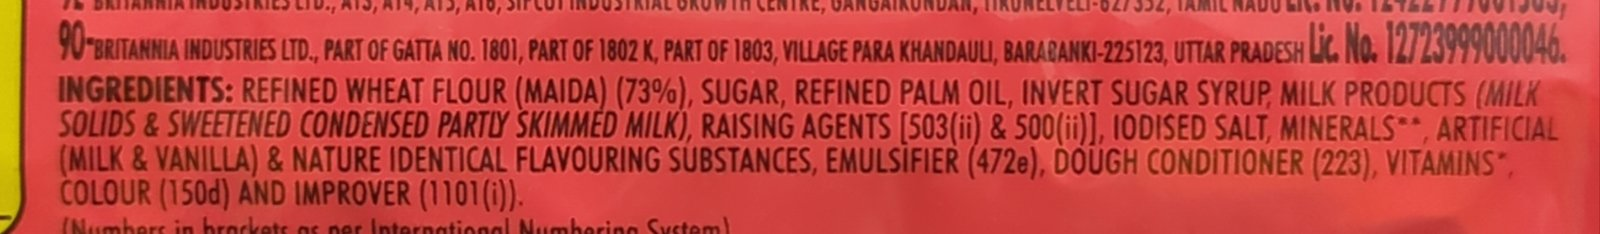

/usr/local/lib/python3.11/dist-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:111.)
  w_ih = torch.quantize_per_tensor(


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ingredient text read from the photo:
 REFINED WHEAT FLOUR (MAIDA) (73%) SUGAR, REFINED PALM OIL, INVERT SUGAR SYRUP MILk products (MIlk ARTIFICIAL (Milk & VANILLA) & NATURE UDENTICAL FLAVOURING SUBSTANCES, EMULSIfIER (472e) , DOUGH CONDITIONER (223), VITAMINS COLOUR (150d) AND IMPROVER (11O0T ()} 

Classifier: ingredient-ner-distilbert


,text,label,canonical_name,function,description
0,REFINED WHEAT FLOUR,INGREDIENT,,,"A food ingredient (e.g. wheat flour, milk soli..."
1,MAIDA,INGREDIENT,,,"A food ingredient (e.g. wheat flour, milk soli..."
2,SUGAR,SUGAR,sugar,,A sugar or syrup added to the food. Labels use...
3,REFINED PALM OIL,FAT,,,"An oil or fat, e.g. palm oil, palmolein, veget..."
4,INVERT SUGAR SYRUP MILk products,INGREDIENT,,,"A food ingredient (e.g. wheat flour, milk soli..."
5,MIlk ARTIFICIAL,INGREDIENT,,,"A food ingredient (e.g. wheat flour, milk soli..."
6,Milk & VANILLA,INGREDIENT,,,"A food ingredient (e.g. wheat flour, milk soli..."
7,NATURE UDENTICAL FLAVOURING SUBSTANCES,FLAVOURING,,,"A flavouring: natural, nature-identical or art..."
8,EMULSIfIER,FUNCTION_CLASS,Emulsifier,Emulsifier,Emulsifiers are substances which make it possi...
9,472e,INS_CODE,Mono- and diacetyltartaric acid esters of mono...,"Emulsifier, Sequestrant, Stabiliser",Emulsifiers are substances which make it possi...


SUGAR         SUGAR
FAT           REFINED PALM OIL
PRESERVATIVE  223 (Sodium metabisulphite)
COLOUR        150d (Sulphite ammonia caramel)
ADDITIVE      472e (Mono- and diacetyltartaric acid esters of mono- and diglycerides of fatty acids), 11O0T
FLAVOURING    NATURE UDENTICAL FLAVOURING SUBSTANCES
INGREDIENT    REFINED WHEAT FLOUR, MAIDA, INVERT SUGAR SYRUP MILk products, MIlk ARTIFICIAL, Milk & VANILLA

Hidden names: {'sugars_under_other_names': [], 'fats_under_other_names': [], 'additives_written_as_codes': ['472e', '223', '150d', '11O0T']}

This tool identifies ingredients and explains what they are and what they are used for. It does not assess whether a product is healthy or safe. OCR and automatic classification can make mistakes: always check the original label.


In [8]:
import pandas as pd
from IPython.display import Image as ShowImage
from src.app.scanner import IngredientScanner

PHOTO = "data/images/packets/8901063162518.jpg"   # any photo of an ingredient list
TEXT = None                                         # e.g. "Sugar, glucose syrup, acidity regulator (INS 330)"

scanner = IngredientScanner("auto")                 # fine-tuned DistilBERT if present, otherwise dictionary rules
if TEXT:
    result = scanner.scan_text(TEXT)
else:
    display(ShowImage(PHOTO, width=350))
    result = scanner.scan_image(PHOTO)
    print("Ingredient text read from the photo:\n", result["text"], "\n")

print("Classifier:", result["ner_model"])
display(pd.DataFrame(result["entities"])[["text", "label", "canonical_name", "function", "description"]])
for category, items in result["summary"]["groups"].items():
    if items:
        print(f"{category:13}", ", ".join(items))
print("\nHidden names:", result["summary"]["hidden"])
print("\n" + result["disclaimer"])